In [1]:
# ! pip install -U seaborn --quiet
# ! pip install -U matplotlib --quiet

In [2]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Data
# methods = ['Voronoi', 'SVM Linear', 'SVM RBF', 'LPTD', 'Random Forest']
# runtimes = [2.99, 5.66, 9.60, 64.28, 414.97]
# colors = ['#4c72b0', '#55a868', '#c44e52', '#8172b2', '#ccb974']

# # Initialize the plot
# plt.figure(figsize=(10, 6))
# sns.set_style("ticks")

# # Create the bar plot
# # Note: Using log=True handles the logarithmic scale automatically
# #bars = plt.bar(methods, runtimes, color=colors, width=0.6, log=True)
# bars = plt.bar(methods, runtimes, color=colors, width=0.6)
# plt.yscale('symlog', linthresh=1)
# plt.ylim(0, 1000)


# # Formatting the axes
# plt.ylabel('Average Runtime (ms)', fontsize=12)
# plt.xlabel('Method', fontsize=12)
# plt.xticks(rotation=30, ha='right', fontsize=11)

# # Adding the numbers on top of the bars
# for bar in bars:
#     yval = bar.get_height()
#     plt.text(bar.get_x() + bar.get_width()/2, yval * 1.1,  # Position label slightly above bar
#              f'{yval:.2f}',
#              ha='center', va='bottom', fontsize=10, fontweight='bold')

# # Adjust y-axis limits to make room for labels
# plt.ylim(1, 1000)

# plt.tight_layout()
# plt.show()



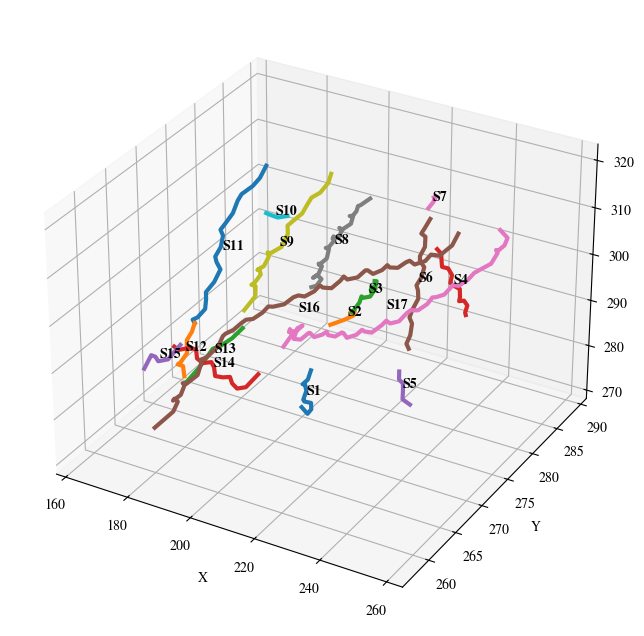

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


df = pd.read_csv('../Archive/5I1M/5I1M_Sticks.csv', header=None, names=['X', 'Y', 'Z', 'Stick_ID'])

# 1. Setup the fonts
plt.rcParams['font.family'] = 'STIXGeneral' #This is exactly 'Times New Roman' but in system
plt.rcParams['mathtext.fontset'] = 'stix'


# 2. Setup the figure
fig = plt.figure(figsize=(10, 8), facecolor='white')
ax = fig.add_subplot(1, 1, 1, projection='3d')

# 3. Iterate through each unique Helix ID to plot
unique_helices = df['Stick_ID'].unique()

for helix_id in unique_helices:
    # Extract data for this specific helix
    helix_data = df[df['Stick_ID'] == helix_id]

    # Plot the 3D line
    # MATLAB equivalent: plot3(..., 'linewidth', 3)
    ax.plot(helix_data['X'], helix_data['Y'], helix_data['Z'], linewidth=3)

    # Calculate the centroid (middle point) for the label
    x_mid = helix_data['X'].mean()
    y_mid = helix_data['Y'].mean()
    z_mid = helix_data['Z'].mean()

    # Add the text label 'H{id}' at the centroid
    # MATLAB equivalent: text(x, y, z, sprintf('H%d', i))
    ax.text(x_mid, y_mid, z_mid, f'S{int(helix_id)}', color='black', fontsize=10, weight='bold')

# 4. Set titles and labels to match the MATLAB code
#ax.set_title('Extracted SSEs-S on PDB for sticks')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.grid(True)

# Show the plot
plt.savefig("../artifacts/3d_stick.png", dpi=300)
plt.show()

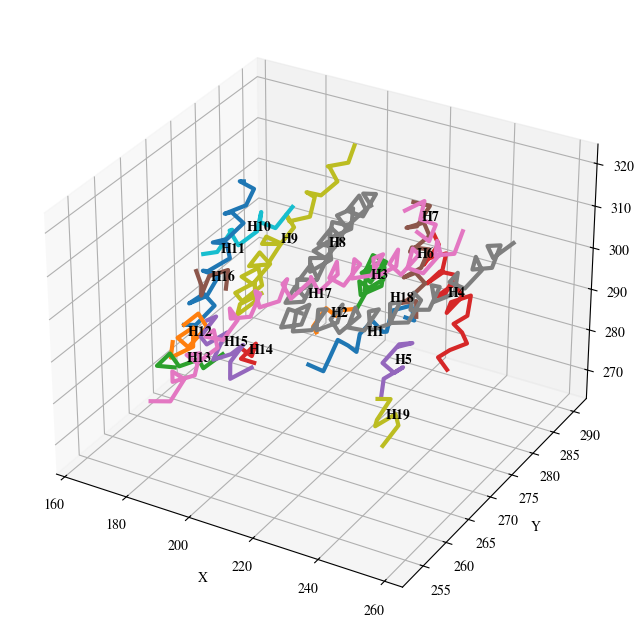

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


df = pd.read_csv('../Archive/5I1M/5I1M_Helices.csv', header=None, names=['X', 'Y', 'Z', 'Helix_ID'])

# 1. Setup the fonts
plt.rcParams['font.family'] = 'STIXGeneral' #This is exactly 'Times New Roman' but in system
plt.rcParams['mathtext.fontset'] = 'stix'


# 2. Setup the figure
fig = plt.figure(figsize=(10, 8), facecolor='white')
ax = fig.add_subplot(1, 1, 1, projection='3d')

# 3. Iterate through each unique Helix ID to plot
unique_helices = df['Helix_ID'].unique()

for helix_id in unique_helices:
    # Extract data for this specific helix
    helix_data = df[df['Helix_ID'] == helix_id]

    # Plot the 3D line
    # MATLAB equivalent: plot3(..., 'linewidth', 3)
    ax.plot(helix_data['X'], helix_data['Y'], helix_data['Z'], linewidth=3)

    # Calculate the centroid (middle point) for the label
    x_mid = helix_data['X'].mean()
    y_mid = helix_data['Y'].mean()
    z_mid = helix_data['Z'].mean()

    # Add the text label 'H{id}' at the centroid
    # MATLAB equivalent: text(x, y, z, sprintf('H%d', i))
    ax.text(x_mid, y_mid, z_mid, f'H{int(helix_id)}', color='black', fontsize=10, weight='bold')

# 4. Set titles and labels to match the MATLAB code
#ax.set_title('Extracted SSEs-S on PDB for helices')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.grid(True)

# Show the plot
plt.savefig("../artifacts/3d_helices.png", dpi=300)
plt.show()

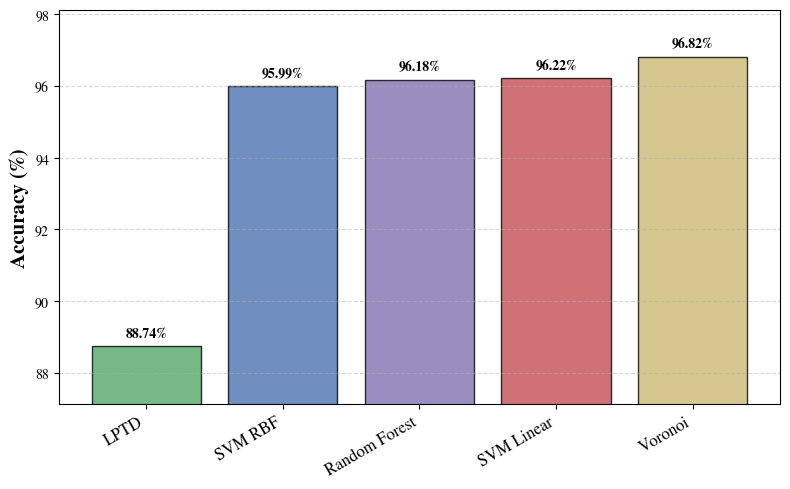

In [ ]:
import matplotlib.pyplot as plt

# ----------------------------------------
# Global font settings (Times New Roman)
# ----------------------------------------
plt.rcParams['font.family'] = 'STIXGeneral' #This is exactly 'Times New Roman' but in system
plt.rcParams['mathtext.fontset'] = 'stix'

charts_data = [
    {
        "title": "Average Performance\n(38 proteins)",
        "data": {
            "SVM RBF": 95.99,
            "LPTD": 88.74,
            "SVM Linear": 96.22,
            "Random Forest": 96.18,
            "Voronoi": 96.82
        }
    },
]

# Color map
method_colors = {
    "SVM RBF": '#4c72b0',
    "LPTD": '#55a868',
    "SVM Linear": '#c44e52',
    "Random Forest": '#8172b2',
    "Voronoi": '#ccb974'
}

# ----------------------------------------
# Single figure / single axis
# ----------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

chart = charts_data[0]

# ---- SORT DATA (ascending) ----
sorted_items = sorted(chart["data"].items(), key=lambda x: x[1])
methods, values = zip(*sorted_items)

colors = [method_colors[m] for m in methods]

# Bars
bars = ax.bar(methods, values, color=colors, edgecolor='black', alpha=0.8)

# ----------------------------------------
# Dynamic y-axis zoom
# ----------------------------------------
min_val, max_val = min(values), max(values)
range_val = max_val - min_val
padding = range_val * 0.2

ax.set_ylim(max(0, min_val - padding), max_val + padding * 0.8)

# ----------------------------------------
# Labels & styling
# ----------------------------------------
ax.set_ylabel("Accuracy (%)", fontsize=15, fontweight='bold')

ax.set_xticks(range(len(methods)))
ax.set_xticklabels(methods, rotation=30, ha='right', fontsize=12) #, fontweight='bold')

ax.grid(axis='y', linestyle='--', alpha=0.5)

# ----------------------------------------
# Value labels
# ----------------------------------------
for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + range_val * 0.02,
        f"{h:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.savefig("../artifacts/accuracy_comparison.png", dpi=300)
plt.show()


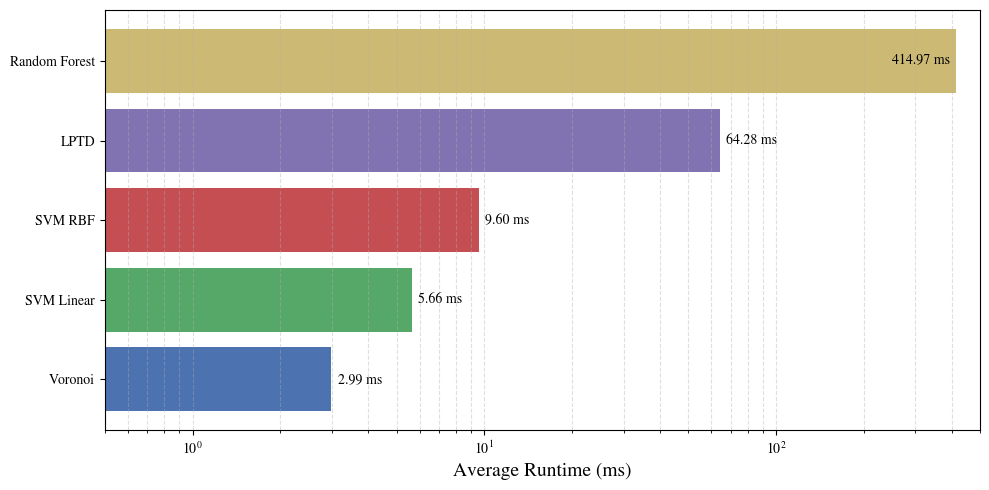

In [ ]:
import matplotlib.pyplot as plt

# ----------------------------------------
# Global font settings (Times New Roman)
# ----------------------------------------
'''
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'
'''
plt.rcParams['font.family'] =   'STIXGeneral' #This is exactly 'Times New Roman' but in system
plt.rcParams['mathtext.fontset'] = 'stix'


methods = ['Voronoi', 'SVM Linear', 'SVM RBF', 'LPTD', 'Random Forest']
runtimes = [2.99, 5.66, 9.60, 64.28, 414.97]
colors = ['#4c72b0', '#55a868', '#c44e52', '#8172b2', '#ccb974']

plt.figure(figsize=(10, 5))
bars = plt.barh(methods, runtimes, color=colors)

# ----------------------------------------
# Log scale and limits
# ----------------------------------------
plt.xscale('log')
plt.xlim(left=0.5, right=500)  # log-scale cannot start at 0

# ----------------------------------------
# Formatting
# ----------------------------------------
plt.xlabel('Average Runtime (ms)', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.4, which='both')

# ----------------------------------------
# Value labels
# ----------------------------------------
for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2

    if width > 100:
        plt.text(
            width * 0.95,
            y,
            f'{width:.2f} ms',
            va='center',
            ha='right'
        )
    else:
        plt.text(
            width * 1.05,
            y,
            f'{width:.2f} ms',
            va='center',
            ha='left'
        )

plt.tight_layout()
plt.savefig("../artifacts/runtime_comparison.png", dpi=300)
plt.show()


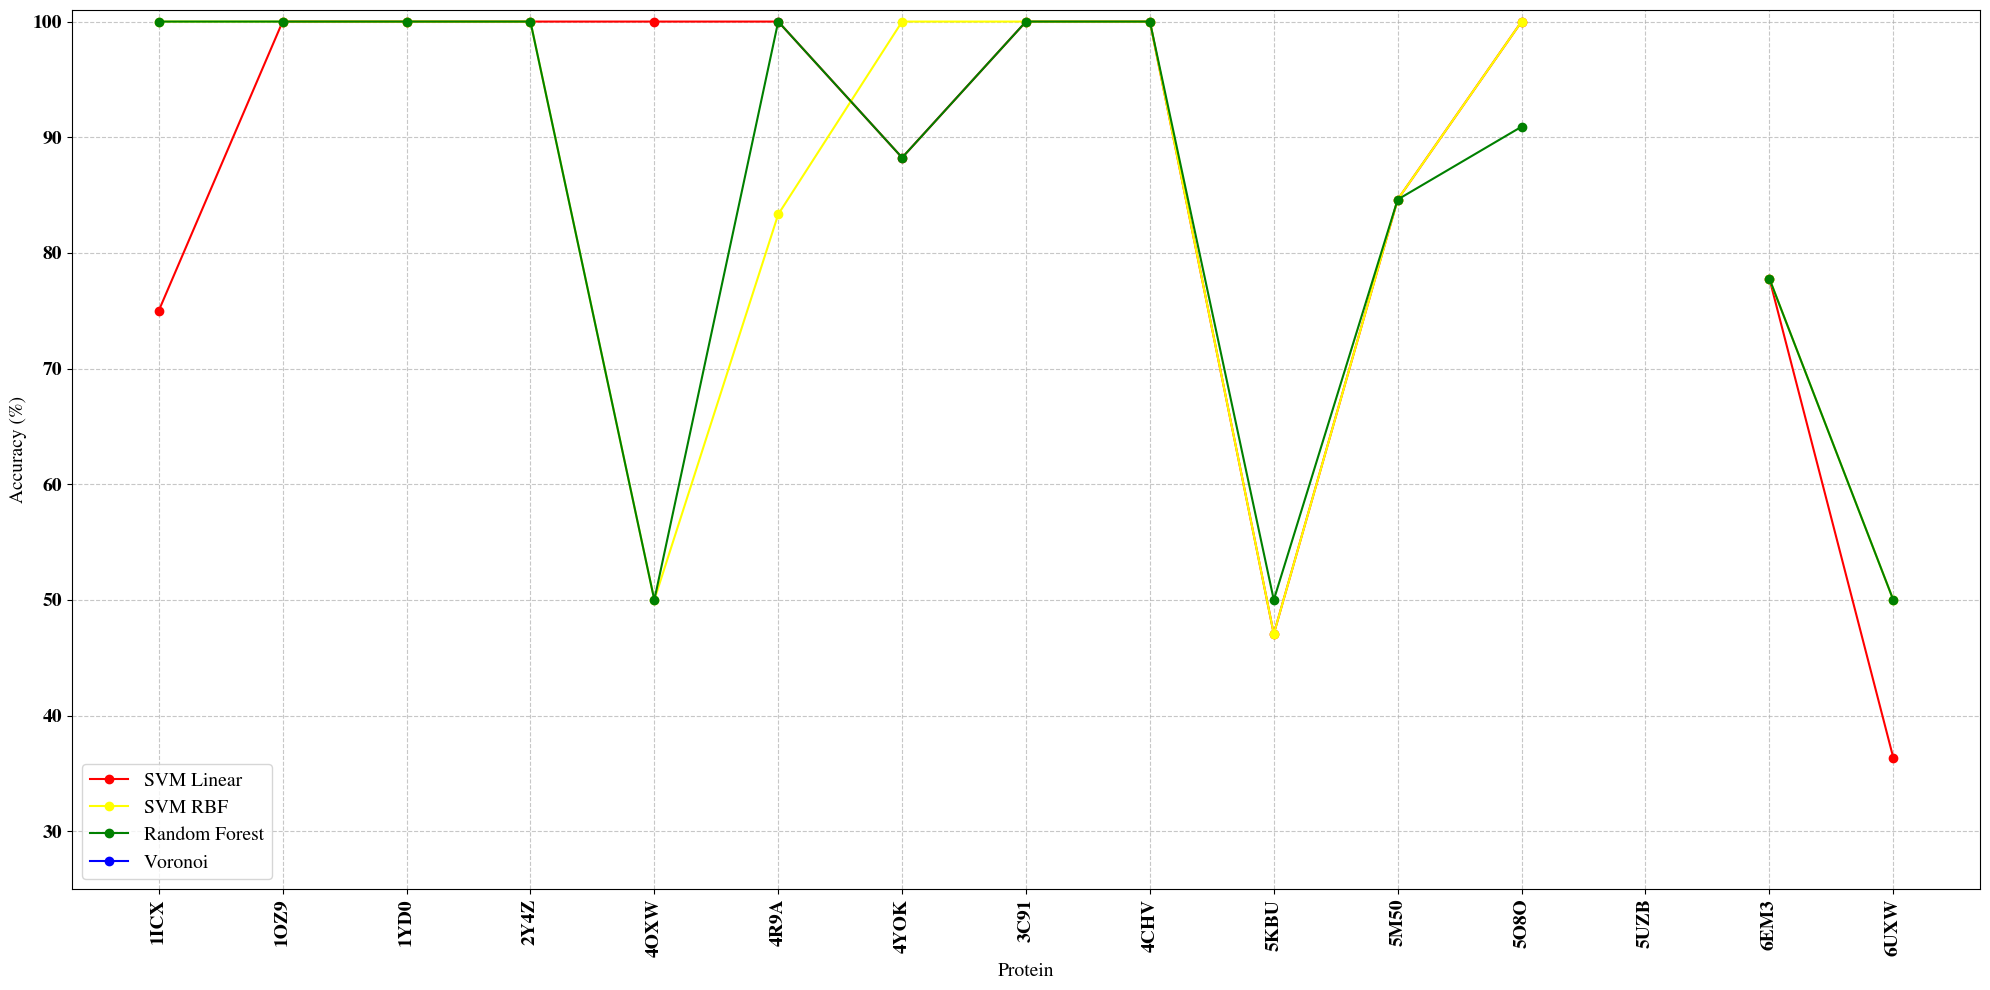

In [ ]:
import matplotlib.pyplot as plt
import json
import numpy as np
from matplotlib.ticker import FuncFormatter

# ----------------------------------------
# Global font settings (Times New Roman)
# ----------------------------------------
plt.rcParams['font.family'] =  'STIXGeneral' #This is exactly 'Times New Roman' but in system
plt.rcParams['mathtext.fontset'] = 'stix'

# ----------------------------------------
# Load the data
# ----------------------------------------
file_path = '../artifacts/Final_Results.json'

with open(file_path, 'r') as f:
    data = json.load(f)

# ----------------------------------------
# Protein order (X-axis)
# ----------------------------------------

protein_order = [
    "1ICX",
    "1OZ9",
    "1YD0",
    "2Y4Z",
    "4OXW",
    "4R9A",
    "4YOK",
    "3C91",
    "4CHV",
    "5KBU",
    "5M50",
    "5O8O",
    "5UZB",
    "6EM3",
    "6UXW"
]


# ----------------------------------------
# Models and colors
# ----------------------------------------
models = [
    ("SVM Linear", "red"),
    ("SVM RBF", "yellow"),
    ("Random Forest", "green"),
    ("Voronoi", "blue")
]

# ----------------------------------------
# Setup the Plot
# ----------------------------------------
plt.figure(figsize=(20, 10))
plt.ylabel("Accuracy (%)", fontsize=14)
plt.xlabel("Protein", fontsize=14)

# ----------------------------------------
# Plot each model
# ----------------------------------------
for model_name, color in models:
    accuracies = []

    for protein in protein_order:
        if (
            protein in data
            and "Strand" in data[protein]
            and model_name in data[protein]["Strand"]
        ):
            # Convert accuracy to percentage
            val = data[protein]["Strand"][model_name]["accuracy"] * 100
            accuracies.append(val)
        else:
            accuracies.append(None)

    plt.plot(
        protein_order,
        accuracies,
        marker='o',
        label=model_name,
        color=color,
        linewidth=1.5
    )

# ----------------------------------------
# Axis formatting
# ----------------------------------------
plt.xticks(rotation=90, fontweight='bold', fontsize=14) #Protein PDBs
plt.yticks(fontweight='bold', fontsize=14) #Percentages

plt.ylim(25, 101.00)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower left', fontsize=14)

plt.tight_layout()

# ----------------------------------------
# Save / Show
# ----------------------------------------
plt.savefig("../artifacts/strands_accuracy.png", dpi=300)
plt.show()


/home/ali/Documents/ml_cryo_etemadheravi_12Jul/.venv/lib/python3.13/site-packages/dateutil/parser/_parser.py:1207: UnknownTimezoneWarning: tzname D identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified but not understood.  "


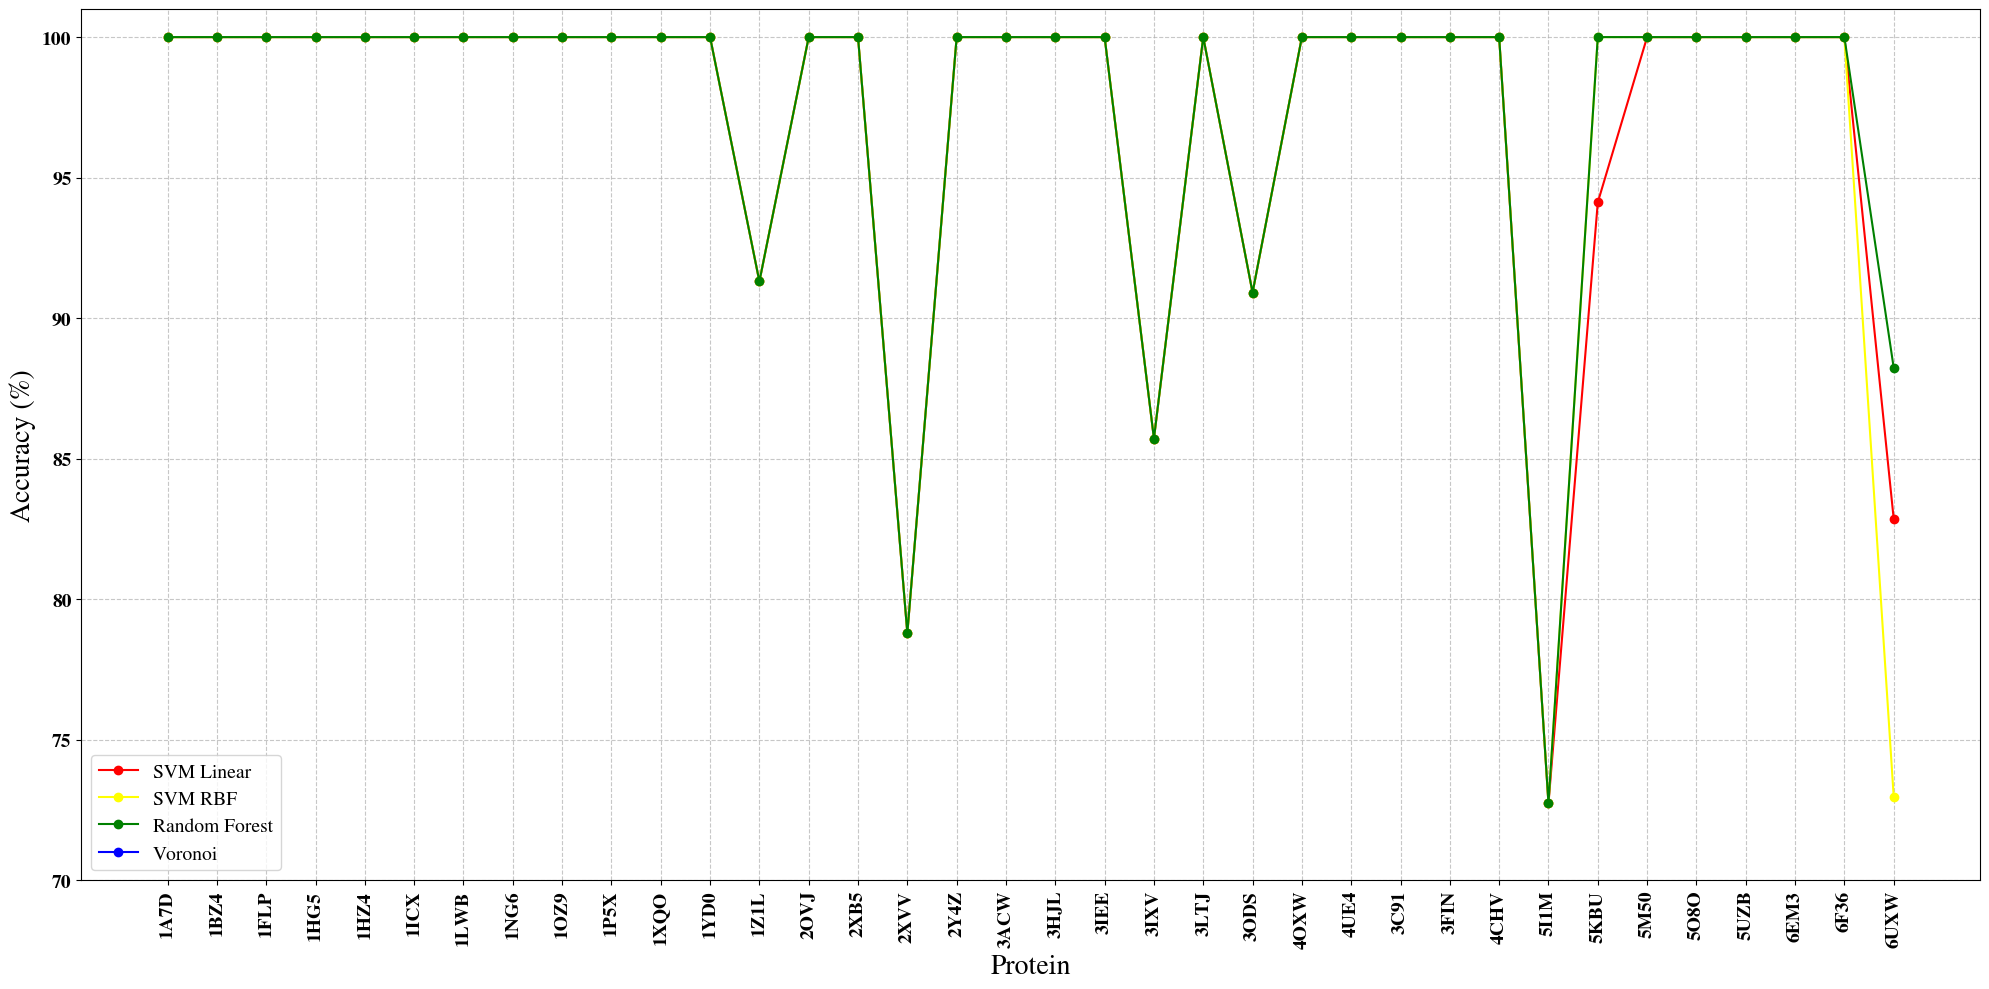

In [ ]:
import matplotlib.pyplot as plt
import json
import numpy as np
from matplotlib.ticker import FuncFormatter

# ----------------------------------------
# Global font settings (Times New Roman)
# ----------------------------------------
plt.rcParams['font.family'] =  'STIXGeneral' #This is exactly 'Times New Roman' but in system
plt.rcParams['mathtext.fontset'] = 'stix'

# ----------------------------------------
# Load the data
# ----------------------------------------
file_path = '../artifacts/Final_Results.json'

with open(file_path, 'r') as f:
    data = json.load(f)

# ----------------------------------------
# Protein order (X-axis)
# ----------------------------------------

protein_order = [
    "1A7D", "1BZ4", "1FLP", "1HG5", "1HZ4", "1ICX", "1LWB", "1NG6",
    "1OZ9", "1P5X", "1XQO", "1YD0", "1Z1L", "2OVJ", "2XB5", "2XVV",
    "2Y4Z", "3ACW", "3HJL", "3IEE", "3IXV", "3LTJ", "3ODS", "4OXW",
    "4UE4", "3C91", "3FIN", "4CHV", "5I1M", "5KBU", "5M50", "5O8O",
    "5UZB", "6EM3", "6F36", "6UXW"
]


# ----------------------------------------
# Models and colors
# ----------------------------------------
models = [
    ("SVM Linear", "red"),
    ("SVM RBF", "yellow"),
    ("Random Forest", "green"),
    ("Voronoi", "blue")
]

# ----------------------------------------
# Setup the Plot
# ----------------------------------------
plt.figure(figsize=(20, 10))
plt.ylabel("Accuracy (%)", fontsize=20)
plt.xlabel("Protein", fontsize=20)

# ----------------------------------------
# Plot each model
# ----------------------------------------
for model_name, color in models:
    accuracies = []

    for protein in protein_order:
        if (
            protein in data
            and "Helix" in data[protein]
            and model_name in data[protein]["Helix"]
        ):
            # Convert accuracy to percentage
            val = data[protein]["Helix"][model_name]["accuracy"] * 100
            accuracies.append(val)
        else:
            accuracies.append(None)

    plt.plot(
        protein_order,
        accuracies,
        marker='o',
        label=model_name,
        color=color,
        linewidth=1.5
    )

# ----------------------------------------
# Axis formatting
# ----------------------------------------
plt.xticks(rotation=90, fontweight='bold', fontsize=14) #Protein PDBs
plt.yticks(fontweight='bold', fontsize=14) # Percentages

plt.ylim(70, 101.00)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower left', fontsize=14)

plt.tight_layout()

# ----------------------------------------
# Save / Show
# ----------------------------------------
plt.savefig("../artifacts/helices_accuracy.png", dpi=300)
plt.show()


In [7]:
!pwd

/home/ali/Documents/ml_cryo_etemadheravi_12Jul/scripts


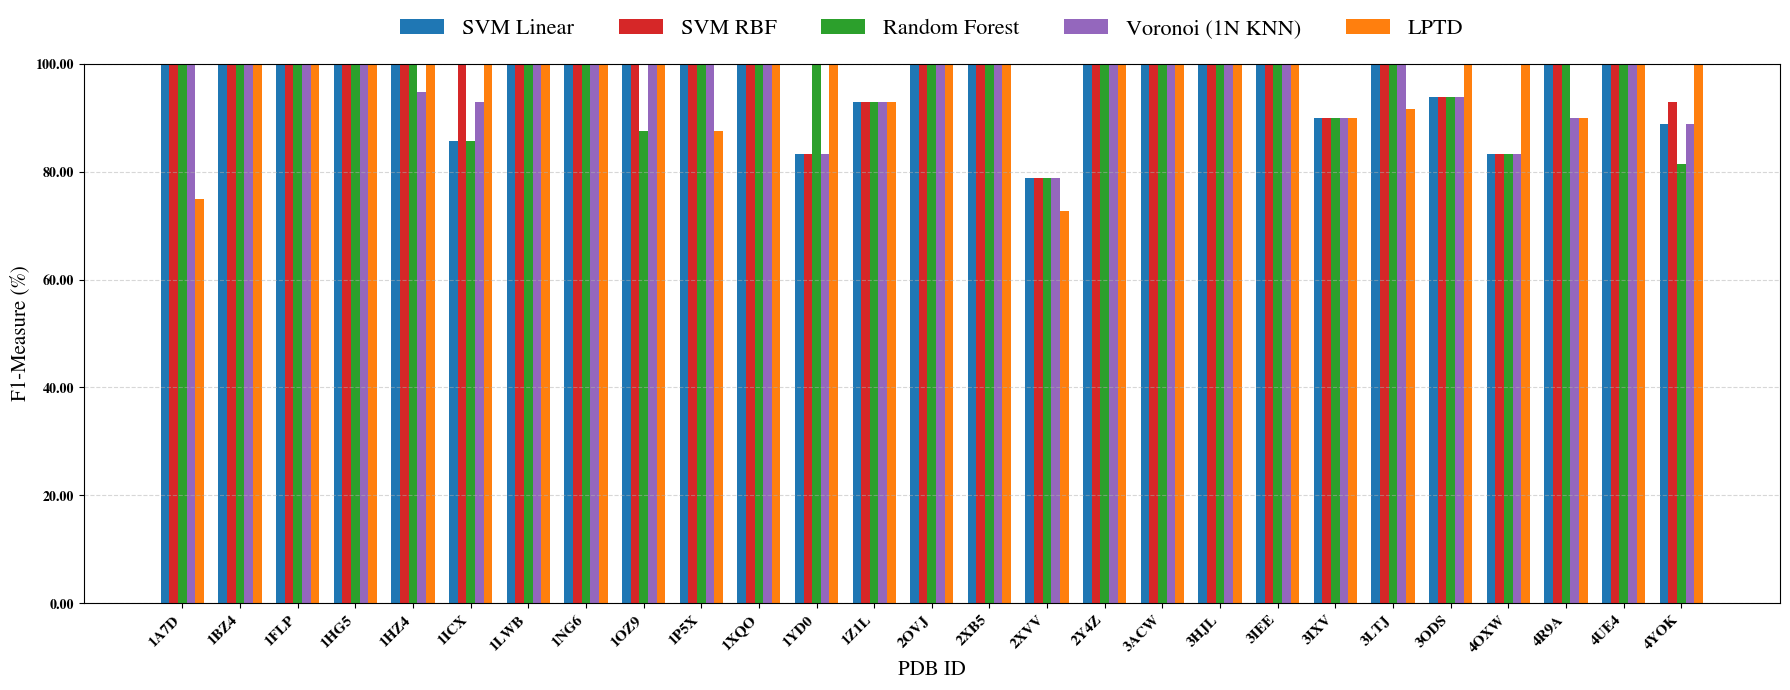

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FormatStrFormatter

# ----------------------------------------
# Configuration
# ----------------------------------------
file_name = '../artifacts/Proteins List.xlsx'
sheet_names = [
    'SVM_Linear',
    'SVM_RBF',
    'Random_Forest',
    'Voronoi_(1N_KNN)',
    'LPTD'
]

custom_order = [
    "1A7D",
    "1BZ4",
    "1FLP",
    "1HG5",
    "1HZ4",
    "1ICX",
    "1LWB",
    "1NG6",
    "1OZ9",
    "1P5X",
    "1XQO",
    "1YD0",
    "1Z1L",
    "2OVJ",
    "2XB5",
    "2XVV",
    "2Y4Z",
    "3ACW",
    "3HJL",
    "3IEE",
    "3IXV",
    "3LTJ",
    "3ODS",
    "4OXW",
    "4R9A",
    "4UE4",
    "4YOK"
]


colors = [
    '#1f77b4',  # blue
    '#d62728',  # red
    '#2ca02c',  # green
    '#9467bd',  # purple
    '#ff7f0e'   # orange
]

# ----------------------------------------
# Data Loading & Merging
# ----------------------------------------
merged_df = pd.DataFrame()

for sheet in sheet_names:
    df = pd.read_excel(file_name, sheet_name=sheet)
    method_name = sheet.replace('_', ' ')

    temp_df = df[['Protein', 'F1-Measure (%)']].copy()
    temp_df.rename(columns={'F1-Measure (%)': method_name}, inplace=True)
    temp_df.set_index('Protein', inplace=True)

    merged_df = temp_df if merged_df.empty else merged_df.join(temp_df, how='outer')

# Keep only requested proteins & order them
merged_df = (
    merged_df
    .loc[merged_df.index.intersection(custom_order)]
    .reindex(custom_order)
)

# Convert percentage to [0, 1]
#merged_df /= 100.0

# ----------------------------------------
# Global font settings (RECOMMENDED)
# ----------------------------------------
plt.rcParams['font.family'] ='STIXGeneral' #This is exactly 'Times New Roman' but in system
plt.rcParams['mathtext.fontset'] = 'stix'

# ----------------------------------------
# Plot: Grouped Bar Chart
# ----------------------------------------
fig, ax = plt.subplots(figsize=(18, 7))

x = np.arange(len(merged_df.index))
bar_width = 0.15

for i, col in enumerate(merged_df.columns):
    ax.bar(
        x + i * bar_width,
        merged_df[col].values,
        width=bar_width,
        color=colors[i],
        label=col
    )

# ----------------------------------------
# Styling
# ----------------------------------------
ax.set_xlabel('PDB ID', fontsize=15)
ax.set_ylabel('F1-Measure (%)', fontsize=15)

# Correct range for F1-measure
ax.set_ylim(0, 1.0)
ax.set_yticks(np.linspace(0, 100.0, 6))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

for label in ax.get_yticklabels():
    label.set_fontweight('bold')

ax.set_xticks(x + bar_width * (len(merged_df.columns) - 1) / 2)
ax.set_xticklabels(
    merged_df.index,
    rotation=45,
    ha='right',
    fontsize=11,
    fontweight='bold'
)

ax.grid(axis='y', linestyle='--', alpha=0.5)

ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 1.12),
    ncol=5,
    frameon=False,
    fontsize=16
)

plt.tight_layout()
plt.savefig('../artifacts/Comparison_F1_simulated.png', dpi=300)
plt.show()
plt.close()


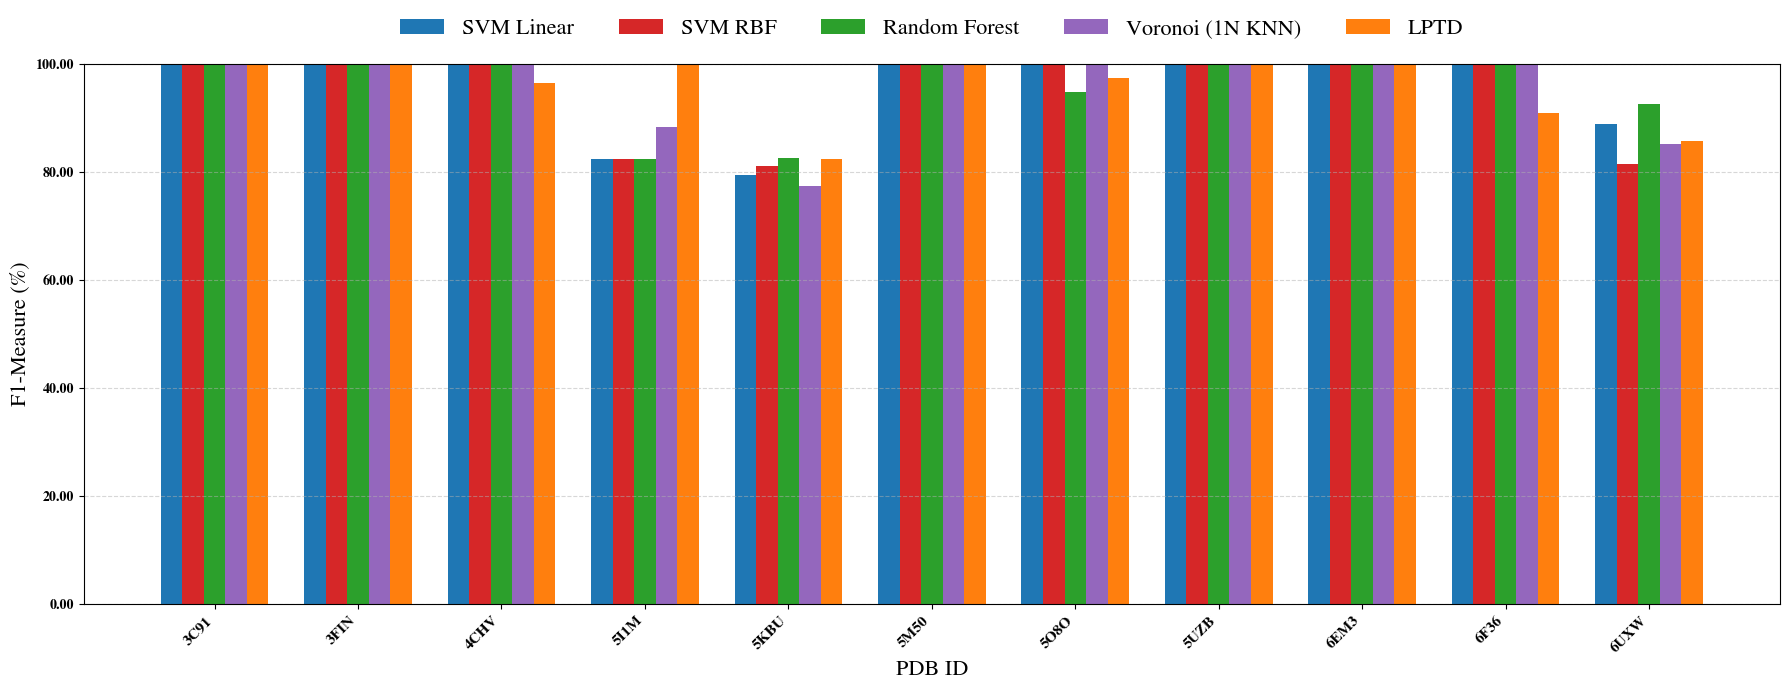

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FormatStrFormatter

# ----------------------------------------
# Configuration
# ----------------------------------------
file_name = '../artifacts/Proteins List.xlsx'
sheet_names = [
    'SVM_Linear',
    'SVM_RBF',
    'Random_Forest',
    'Voronoi_(1N_KNN)',
    'LPTD'
]

custom_order = [
    "3C91", "3FIN", "4CHV", "5I1M", "5KBU",
    "5M50", "5O8O", "5UZB", "6EM3", "6F36", "6UXW"
]


#colors = ['#4F81BD', '#C0504D', '#9BBB59', '#8064A2', '#4BACC6']

colors = [
    '#1f77b4',  # blue
    '#d62728',  # red
    '#2ca02c',  # green
    '#9467bd',  # purple
    '#ff7f0e'   # orange
]

# ----------------------------------------
# Data Loading & Merging
# ----------------------------------------
merged_df = pd.DataFrame()

for sheet in sheet_names:
    df = pd.read_excel(file_name, sheet_name=sheet)
    method_name = sheet.replace('_', ' ')

    temp_df = df[['Protein', 'F1-Measure (%)']].copy()
    temp_df.rename(columns={'F1-Measure (%)': method_name}, inplace=True)
    temp_df.set_index('Protein', inplace=True)

    merged_df = temp_df if merged_df.empty else merged_df.join(temp_df, how='outer')

# Keep only requested proteins & order them
merged_df = (
    merged_df
    .loc[merged_df.index.intersection(custom_order)]
    .reindex(custom_order)
)

# Convert percentage to [0, 1]
#merged_df /= 100.0

# ----------------------------------------
# Global font settings (RECOMMENDED)
# ----------------------------------------
plt.rcParams['font.family'] =  'STIXGeneral' #This is exactly 'Times New Roman' but in system
plt.rcParams['mathtext.fontset'] = 'stix'

# ----------------------------------------
# Plot: Grouped Bar Chart
# ----------------------------------------
fig, ax = plt.subplots(figsize=(18, 7))

x = np.arange(len(merged_df.index))
bar_width = 0.15

for i, col in enumerate(merged_df.columns):
    ax.bar(
        x + i * bar_width,
        merged_df[col].values,
        width=bar_width,
        color=colors[i],
        label=col
    )

# ----------------------------------------
# Styling
# ----------------------------------------
ax.set_xlabel('PDB ID', fontsize=16)
ax.set_ylabel('F1-Measure (%)', fontsize=16)

# Correct range for F1-measure
ax.set_ylim(0, 1.0)
ax.set_yticks(np.linspace(0, 100.0, 6))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

for label in ax.get_yticklabels():
    label.set_fontweight('bold')

ax.set_xticks(x + bar_width * (len(merged_df.columns) - 1) / 2)
ax.set_xticklabels(
    merged_df.index,
    rotation=45,
    ha='right',
    fontsize=11,
    fontweight='bold'
)

ax.grid(axis='y', linestyle='--', alpha=0.5)

ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 1.12),
    ncol=5,
    frameon=False,
    fontsize=16 # methods
)

plt.tight_layout()
plt.savefig('../artifacts/Comparison_F1_real.png', dpi=300)
plt.show()
plt.close()
